# W + Charm Analysis:

This analysis is done using `Coffea` (version 2024.10.0) and `Awkward Arrays`. This study will focus on the event selection of W+c Events. This analysis will focus on the selection of W+c Events. The dataset used for this is: [W1JetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v1/NANOAODSIM](https://opendata.cern.ch/record/69545).

In [1]:
import hist as h
import dask
import awkward as ak
import hist.dask as dhist
import dask_awkward as dak
import uproot
import numpy as np
import mplhep as mh
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import matplotlib.pyplot as plt

NanoAODSchema.warn_missing_crossrefs = False

In [2]:
events = NanoEventsFactory.from_root(
    {"../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_250K.root": "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

dask.awkward<from-uproot, npartitions=1>

In [3]:
# Defining the style for plots (CMS Style)
plt.style.use(mh.style.CMS)
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# Histogram Function:
def make_hist(data, nBins, lo, hi, xLabel, yLabel, label, fname=None, logy=False):
    histogram = dhist.Hist(h.axis.Regular(nBins, lo, hi))
    fig, ax = plt.subplots(1 ,1, figsize=(6,4))
    histogram.fill(data)
    # histogram.compute().plot(ax=ax , yerr=False, label=label)  
    mh.histplot(histogram.compute(), ax=ax, label=label, yerr=False, histtype="step") 
    mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)
    ax.legend()
    if logy:
        ax.set_yscale("log")
    if fname:
        plt.savefig(fname)
    plt.show()

## Event Selection:

Approach to Event Selection:

- Select events with at least two muons.
- Make selection of $\bf{W}$ from $W \rightarrow \mu + \nu$ process. Make selection of $\mu$ that are associated with a $W$. The $\mu$ are selected on the basis:
    1. $p_{T}$ > 35 GeV (high-$p_{T}$).
    2. $\eta$ < 2.4.
    3. `pfRelIso04_all` < 0.15 (isolated).
    4. `tightId` == True/1.
- This gives our W candidates.
- Make selection of $c$ from $H_{c} \rightarrow \mu + X$ process. Make selection of non-isolated, soft muons and then make selections of jets associated with these soft muons.
    1. $p_{T}$ < 20 GeV. (soft-muons)
    2. $\eta$ < 2.4.
    3. `pfRelIso04_all` > 0.2 (non-isolated).
    4. `tightId` == True/1.
- Then we match the muons with the jets (using `JetIdx`).
- This gives are c-Jet candidates.

In [4]:
# Events with atleast 2 muons:
nMu = dak.num(events.Muon.pt)
EventSelection = (nMu >= 2)
events = events[EventSelection]

# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet

In [5]:
# W -> Mu Nu Channel Selection:
W_MuMask = (
    (Muon.pt > 30) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == True) &
    (Muon.pfRelIso04_all < 0.15)
    )
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]
# Select events with exactly one W muon:
nMu = dak.num(W_Muons.pt)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

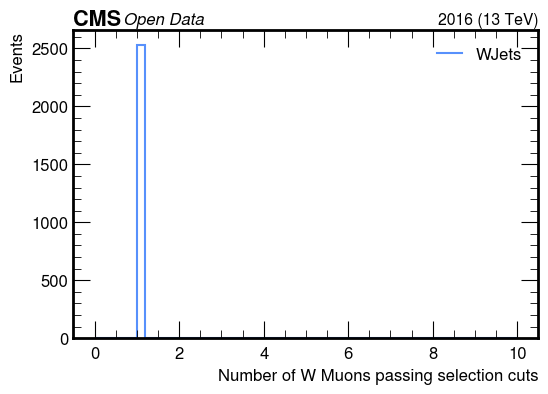

In [6]:
n_WMu = dak.num(W_Muons.pt)
make_hist(
    n_WMu,
    50, 0, 10,
    "Number of W Muons passing selection cuts",
    "Events",
    "WJets",
    fname=None,
    logy=False
)

In [7]:
# C-jet -> Mu X Channel Selection:
cMuPassCuts = (
    (Muon.pt < 20) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) &
    (Muon.tightId == 1)
)
soft_muon = Muon[cMuPassCuts]

# Require the muon be matched to a jet (jetIdx >= 0)
soft_muon_injet = soft_muon[soft_muon.jetIdx >= 0]

# Get the matched jet for each selected muon
matched_jet = Jet[soft_muon_injet.jetIdx]

# Apply jet cuts on the *matched jets*
Jet_PassCuts = (
    (matched_jet.pt > 30) & 
    (abs(matched_jet.eta) < 2.4)
)

# Keep only muons whose matched jet passes jet cuts
soft_muon_in_goodjet = soft_muon_injet[Jet_PassCuts]
c_Jets = matched_jet[Jet_PassCuts]
nC_Jets = dak.num(c_Jets.pt)
# Select events with atleast one c-jet:
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

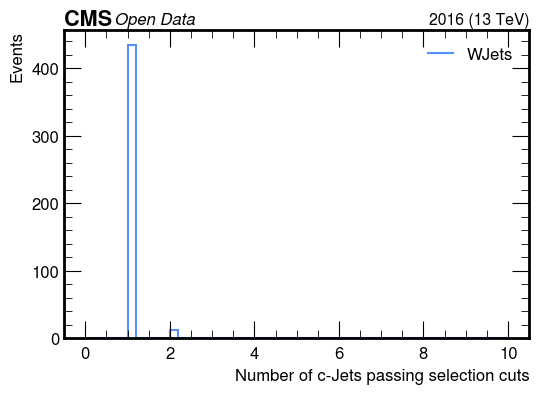

In [13]:
ncJets = dak.num(c_Jets.pt)
make_hist(
    ncJets,
    50, 0, 10,
    "Number of c-Jets passing selection cuts",
    "Events",
    "WJets",
    fname=None,
    logy=False
)

Selecting events that has both $W$ and $c$-jets and then plotting there observables.  

In [9]:
Wc_Events = events[evt_has_1WMu & evt_has_cJet]

In [14]:
Wc_Muons = Wc_Events.Muon
Wc_Jets = Wc_Events.Jet

nWcMuons = dak.num(Wc_Muons.pt)
nWcJets = dak.num(Wc_Jets.pt)

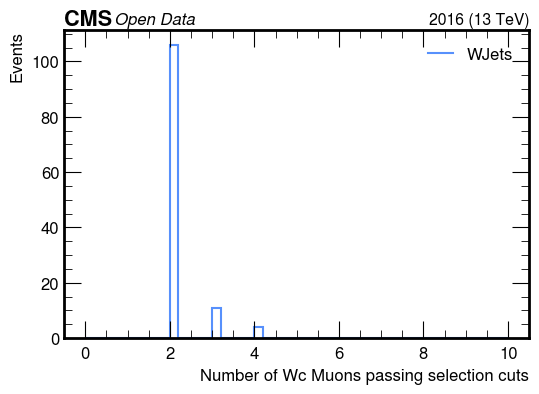

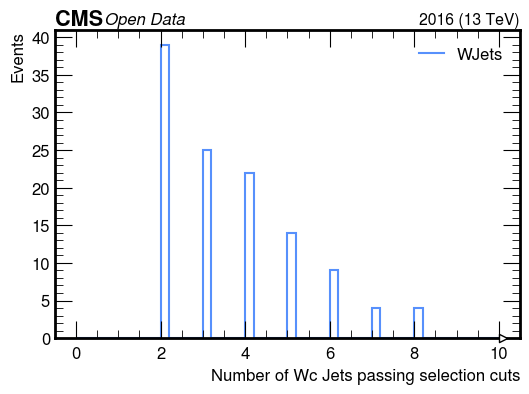

In [15]:
make_hist(
    nWcMuons,
    50, 0, 10,
    "Number of Wc Muons passing selection cuts",
    "Events",
    "WJets",
    fname=None,
    logy=False
)

make_hist(
    nWcJets,
    50, 0, 10,
    "Number of Wc Jets passing selection cuts",
    "Events",
    "WJets",
    fname=None,
    logy=False
)

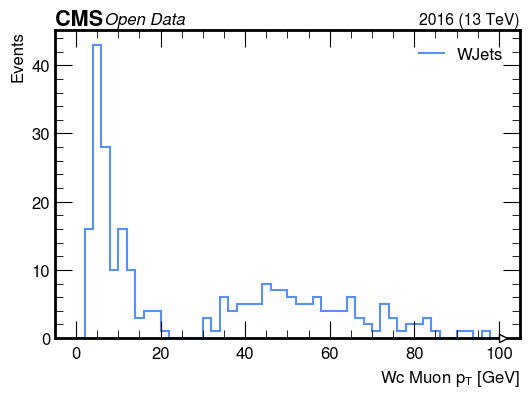

In [20]:
WcMuon_Pt = dak.flatten(Wc_Muons.pt)
make_hist(
    WcMuon_Pt,
    50, 0, 100,
    "Wc Muon $p_{T}$ [GeV]",
    "Events",
    "WJets",
    fname=None,
    logy=False
)

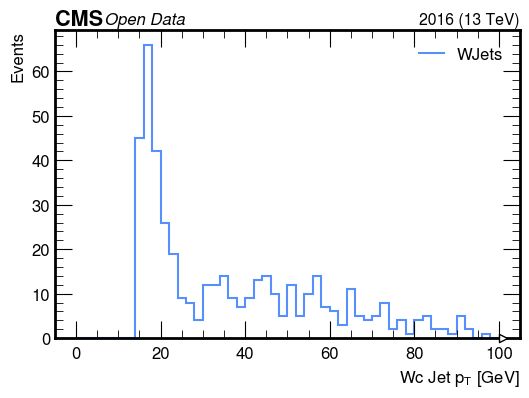

In [19]:
WcJet_Pt = dak.flatten(Wc_Jets.pt)
make_hist(
    WcJet_Pt,
    50, 0, 100,
    "Wc Jet $p_{T}$ [GeV]",
    "Events",
    "WJets",
    fname=None,
    logy=False
)